$$
\begin{aligned}
\tau \dot{V}(t) &= -V(t) + u(t) \\
\text{Where: } V(t) &: \text{State of the system} \\
u(t) &: \text{External driver} \\
\tau &: \text{Time constant}
\end{aligned}
$$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

dt = 0.001        
T = 5             
t = np.arange(0, T, dt)

tau = 0.5         


In [ ]:
t

array([0.000e+00, 1.000e-03, 2.000e-03, ..., 4.997e+00, 4.998e+00,
       4.999e+00])

$$\begin{aligned}
& \text{We discretize continuous time using the \textbf{Euler method:}} \\
& \text{There is a single state variable called } V(t). \\
& \text{At each step, we perform the following update:} \\
& V(t + dt) = V(t) + \frac{dt}{\tau}(-V(t) + u(t))
\end{aligned}$$

[1. 1. 1. ... 1. 1. 1.]
[0.         0.002      0.003996   ... 0.99995478 0.99995487 0.99995496]


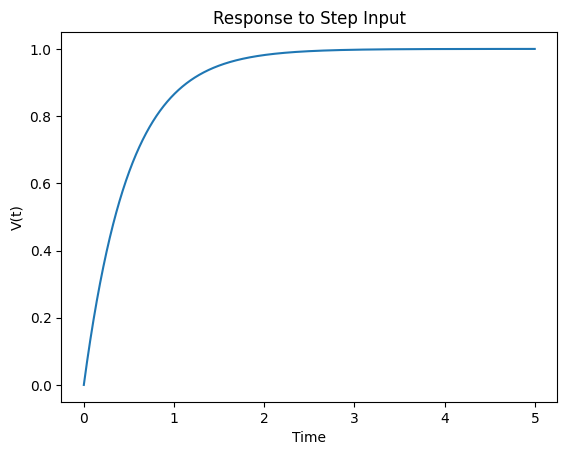

In [ ]:
u_step = np.ones_like(t)   # u(t) = 1
V = np.zeros_like(t)       # başlangıç: V(0)=0

for i in range(1, len(t)):
    V[i] = V[i-1] + dt * ( -V[i-1] + u_step[i] ) / tau


print(u_step)
print(V)

plt.figure()
plt.plot(t, V)
plt.title("Response to Step Input")
plt.xlabel("Time")
plt.ylabel("V(t)")
plt.show()


V(t) starts from zero
and with a single constant speed
smoothly, without ever overflowing,
approaches a fixed value.
What does this show?
Single time scale
The shape of the curve is the same everywhere.
Even though it looks fast at the beginning and slower later,
mathematically it’s just one single exponential.
If there were two time scales, you would see:
a fast initial rise
followed by a much slower settling phase.
But there isn’t.
No memory
The system doesn’t care “what happened in the beginning”.
Whatever the current V is right now,
only that value determines the future.
In other words:
The entire past has been compressed into a single number (V).

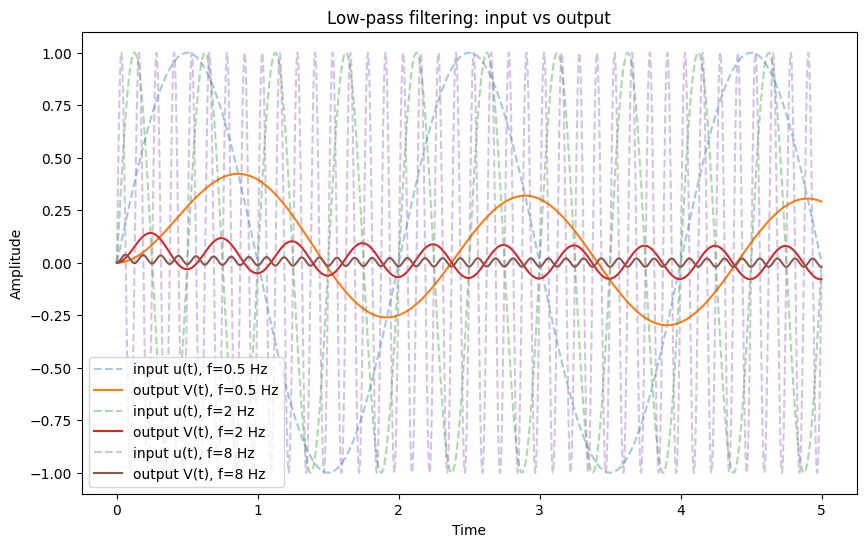

In [ ]:
# Visualizing input u(t) together with output V(t) for better intuition
import numpy as np
import matplotlib.pyplot as plt

dt = 0.001
T = 5
t = np.arange(0, T, dt)

tau = 1.0
freqs = [0.5, 2, 8]  # Hz

plt.figure(figsize=(10, 6))

for f in freqs:
    u = np.sin(2 * np.pi * f * t)
    V = np.zeros_like(t)

    for i in range(1, len(t)):
        V[i] = V[i-1] + dt * ( -V[i-1] + u[i] ) / tau

    plt.plot(t, u, linestyle="--", alpha=0.4, label=f"input u(t), f={f} Hz")
    plt.plot(t, V, label=f"output V(t), f={f} Hz")

plt.title("Low-pass filtering: input vs output")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.legend()
plt.show()


This is what it means:

u(t) → the input signal entering the system
V(t) → the system's output/response
τ (tau) → how "slowly" / how "lazily" the system responds
• Larger τ → heavier, more sluggish, stronger smoothing/filtering
• Smaller τ → faster response, less smoothing/filtering

This is a classic low-pass filter.
In other words:
A low-pass filter lets the slow parts through and suppresses the fast parts.
• It passes low frequencies
• It attenuates/suppresses high frequencies

How should the graph be read?
f = 0.5 Hz (slow input)
• The input is changing very slowly
• The system can easily follow it
• V(t) looks quite similar to u(t)
✓ Low frequency is passed
f = 2 Hz (medium speed)
• The input starts changing faster
• The system begins to lag behind
• The amplitude gets smaller, phase shift appears
 Partial suppression / attenuation
f = 8 Hz (very fast)
• The input is jumping around like crazy
• The system can’t keep up at all
• V(t) is almost a flat line
✗ High frequency is heavily suppressed
This is exactly what a low-pass filter does